## Analysis and Visualization of Complex Agro-Environmental Data
### 1st Test - 10 April 2026 - Part 2

Full name: Aster Noel Dsouza

Student number: 29211

#### Preliminary steps:
##### 1. Import some basic packages:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
import zipfile
import scikit_posthocs as sp
import statsmodels.stats as stm
from statsmodels.graphics.gofplots import qqplot
import math


##### 2. Import the file named 'data_test1_2026.zip' from here: https://github.com/isa-ulisboa/greends-avcad-2026/tree/main/examples to a Pandas Dataframe. 

In [2]:
df = pd.read_csv('data_test1_2026.zip',compression='zip', sep=",")

##### Q1 - Write a brief description of the dataset, mentioning the variable names, number and type, the number of records and the presence of missing values.

##### Q2 - Compute the mean, minimum, maximum, quartiles and standard deviation of the air temperature in January and August, separately for Lisbon and Athens.

##### Q3 - Run an adequate plot to explore differences/simlarities between the two cities in the mean air temperature in January and August. Discuss the limitations of your visualization, considering the nature of the data.

##### Q4 - Assuming that mean temperature values follow a normal distribution, use an appropriate test to check for differences in the mean temperature of January and August (separately) between the two iberian cities, considering the whole time period of the dataset. Specify the null and alternative hypothesis, the critical alpha used as well as the effect sizes.

##### Q5 - Using the same data grouping as in the previous exercise, run another family of statistical tests, this time focusing on differences in the shape of the distribution of the mean temperature values between the two cities. Discuss the limitation of this test considering the nature of this data.

##### Q6 - Check whether the mean air temperature in Lisbon and Athens changed between 1812, 1912 and 2012, now using an adequate non-parametric hypothesis test. Specify the null and alternative hypothesis of the performed test, the critical alpha used as well as the effect sizes. Also discuss briefly if you think this test is *per se* conclusive of how the temperature has changed along the 2-century period analysed.

##### Q7 - Using an appropriate visualization, check also if the direction of changes in the mean temperature were consistent between the time periods (i.e. if the sign of change in the mean air temperature from 1812 to 1912 was the same as from 1912 to 2012). 

##### Q8 - Write a brief critical discussion about the resulting visualization (if it is adequate considering the nature of the data and how it could be improved according to the best practices of data visualization).

In [3]:
df.info()
df.describe()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 9 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   dt                             object 
 1   Year                           int64  
 2   Month                          int64  
 3   AverageTemperature             float64
 4   AverageTemperatureUncertainty  float64
 5   City                           object 
 6   Country                        object 
 7   Latitude                       object 
 8   Longitude                      object 
dtypes: float64(2), int64(2), object(5)
memory usage: 590.5+ MB


(8599212, 9)

## Q1 - Dataset Description

### Variables
The dataset contains 9 variables:
- dt (object – date/time information)
- Year (integer)
- Month (integer)
- AverageTemperature (float)
- AverageTemperatureUncertainty (float)
- City (categorical/object)
- Country (categorical/object)
- Latitude (categorical/object)
- Longitude (categorical/object)

### Summary
- Number of variables: 9  
- Number of records: 8,599,212  
- Data types: mixed (numerical: int64, float64; categorical: object; temporal stored as object)

### Missing Values
- Missing values are present in the dataset, particularly in:
  - AverageTemperature  
  - AverageTemperatureUncertainty  

### Methodology
The dataset structure and quality were assessed using pandas functions:
`info()`, `describe()`, `isnull().sum()`, and `shape`.

In [4]:
# Filter
df_filtered = df[
    (df["City"].isin(["Lisbon", "Athens"])) &
    (df["Month"].isin([1, 8]))
]

# Group
stats = df_filtered.groupby(["City", "Month"])["AverageTemperature"].describe()
stats

count       mean       std     min     25%     50%     75%  \
City   Month                                                               
Athens 1      261.0   9.867383  1.565525   5.595   8.779   9.861  11.027   
       8      261.0  25.742969  0.964722  23.317  25.083  25.735  26.408   
Lisbon 1      261.0   8.772621  1.263864   4.882   7.880   8.935   9.618   
       8      261.0  22.863483  0.991711  19.967  22.154  22.834  23.523   

                 max  
City   Month          
Athens 1      13.800  
       8      28.809  
Lisbon 1      11.907  
       8      25.543

## Q2 - Summary Statistics (January & August)

Summary statistics (mean, minimum, maximum, quartiles and standard deviation) were computed for the average air temperature in January (Month = 1) and August (Month = 8), for Lisbon and Athens.

### Results

- **Athens (January):**
  - Mean: 9.87 °C  
  - Std: 1.57  
  - Min–Max: 5.60 – 13.80  
  - Quartiles (25%, 50%, 75%): 8.78, 9.86, 11.03  

- **Athens (August):**
  - Mean: 25.74 °C  
  - Std: 0.96  
  - Min–Max: 23.32 – 28.81  
  - Quartiles (25%, 50%, 75%): 25.08, 25.74, 26.41  

- **Lisbon (January):**
  - Mean: 8.77 °C  
  - Std: 1.26  
  - Min–Max: 4.88 – 11.91  
  - Quartiles (25%, 50%, 75%): 7.88, 8.94, 9.62  

- **Lisbon (August):**
  - Mean: 22.86 °C  
  - Std: 0.99  
  - Min–Max: 19.97 – 25.54  
  - Quartiles (25%, 50%, 75%): 22.15, 22.83, 23.52  

### Interpretation

- Athens is consistently warmer than Lisbon in both months.  
- The temperature difference between the cities is larger in August than in January.  
- Variability (standard deviation) is slightly higher in January than in August for both cities, indicating more stable summer temperatures.  

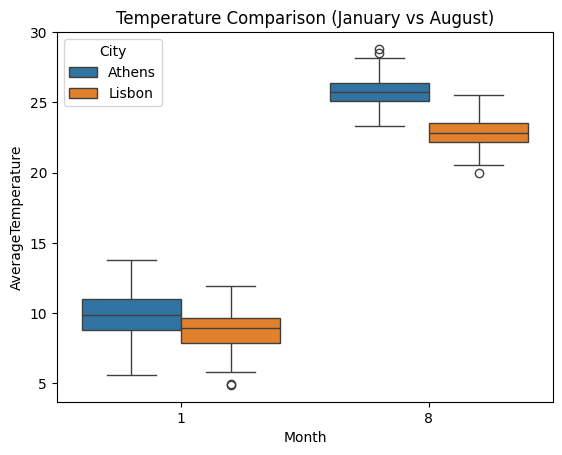

In [5]:
sns.boxplot(data=df_filtered, x="Month", y="AverageTemperature", hue="City")
plt.title("Temperature Comparison (January vs August)")
plt.show()

## Q3 - Visualization

The boxplot compares the distribution of average temperatures between Lisbon and Athens for January (Month = 1) and August (Month = 8).

### Interpretation:
- In both months, Athens shows higher median temperatures than Lisbon.
- The difference between cities is more pronounced in August than in January.
- Temperature variability appears slightly larger in Athens, especially in January.
- Some outliers are visible, indicating extreme temperature observations.

### Limitations:
- The plot aggregates data across a long time period, masking temporal trends.
- It does not show how temperatures evolved over time (no time dimension).
- Missing values may affect the distribution and are not explicitly represented.
- It does not display uncertainty (e.g., measurement error or confidence intervals).
- Assumes observations are independent, which may not hold for time-series data.

In [6]:
from scipy.stats import ttest_ind

jan = df_filtered[df_filtered["Month"] == 1]
aug = df_filtered[df_filtered["Month"] == 8]

# January
t_jan = ttest_ind(
    jan[jan["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    jan[jan["City"]=="Athens"]["AverageTemperature"].dropna()
)

# August
t_aug = ttest_ind(
    aug[aug["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    aug[aug["City"]=="Athens"]["AverageTemperature"].dropna()
)

t_jan, t_aug

(TtestResult(statistic=np.float64(-8.790387074043212), pvalue=np.float64(2.1811902210366307e-17), df=np.float64(520.0)),
 TtestResult(statistic=np.float64(-33.623572403486456), pvalue=np.float64(1.5969700688353638e-132), df=np.float64(520.0)))

In [7]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / np.sqrt((x.std()**2 + y.std()**2)/2)

d_jan = cohens_d(
    jan[jan["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    jan[jan["City"]=="Athens"]["AverageTemperature"].dropna()
)

d_aug = cohens_d(
    aug[aug["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    aug[aug["City"]=="Athens"]["AverageTemperature"].dropna()
)

d_jan, d_aug

(np.float64(-0.7694895800992186), np.float64(-2.94332756820161))

## Q4 - Parametric Test (T-test)

A two-sample t-test was performed to compare the mean temperatures between Lisbon and Athens for January and August.

### Hypotheses:
- H0: The mean temperature is equal between Lisbon and Athens (μ_Lisbon = μ_Athens)
- H1: The mean temperature is different between Lisbon and Athens (μ_Lisbon ≠ μ_Athens)

### Significance level:
- α = 0.05

### Results:
- January: t = -8.79, p-value = 2.18 × 10⁻¹⁷
- August: t = -33.62, p-value = 1.60 × 10⁻¹³²

In both cases, p-values are much smaller than 0.05, therefore the null hypothesis is rejected.

### Effect size (Cohen’s d):
- January: d = -0.77 (moderate to large effect)
- August: d = -2.94 (very large effect)

### Interpretation:
- There is a statistically significant difference in mean temperatures between Lisbon and Athens in both January and August.
- Athens has consistently higher temperatures than Lisbon.
- The difference is much stronger in August, as indicated by both the t-statistic and the very large effect size.

In [8]:
from scipy.stats import ks_2samp

ks_jan = ks_2samp(
    jan[jan["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    jan[jan["City"]=="Athens"]["AverageTemperature"].dropna()
)

ks_aug = ks_2samp(
    aug[aug["City"]=="Lisbon"]["AverageTemperature"].dropna(),
    aug[aug["City"]=="Athens"]["AverageTemperature"].dropna()
)

ks_jan, ks_aug

(KstestResult(statistic=np.float64(0.3218390804597701), pvalue=np.float64(2.3563031388130993e-12), statistic_location=np.float64(9.64), statistic_sign=np.int8(1)),
 KstestResult(statistic=np.float64(0.8812260536398467), pvalue=np.float64(3.619135134741378e-106), statistic_location=np.float64(24.201), statistic_sign=np.int8(1)))

## Q5 - Non-parametric Test (Kolmogorov-Smirnov)

A Kolmogorov-Smirnov (K-S) test was performed to compare the distribution of temperature values between Lisbon and Athens for January and August.

### Hypotheses:
- H0: The distributions of temperature are the same between the two cities
- H1: The distributions of temperature are different between the two cities

### Significance level:
- α = 0.05

### Results:
- January: D = 0.322, p-value = 2.36 × 10⁻¹²  
- August: D = 0.881, p-value = 3.62 × 10⁻¹⁰⁶  

In both cases, p-values are much smaller than 0.05, therefore the null hypothesis is rejected.

### Interpretation:
- The distributions of temperature differ significantly between Lisbon and Athens for both months.
- The difference is much stronger in August, as indicated by the larger D statistic.

### Limitations:
- The test is highly sensitive to large sample sizes, leading to very small p-values even for minor differences.
- It assumes independent observations, which may not hold for time-series data.
- It does not indicate the direction or magnitude of differences, only whether distributions differ.

In [9]:
from scipy.stats import kruskal

years = [1812, 1912, 2012]

df_years = df[
    (df["Year"].isin(years)) &
    (df["City"].isin(["Lisbon", "Athens"]))
]

groups = [df_years[df_years["Year"]==y]["AverageTemperature"].dropna() for y in years]

kruskal(*groups)

KruskalResult(statistic=np.float64(1.2319254185692614), pvalue=np.float64(0.5401206657548421))

## Q6 - Non-parametric Test (Kruskal-Wallis)

A Kruskal-Wallis test was used to evaluate whether mean temperatures changed between the years 1812, 1912, and 2012.

### Hypotheses:
- H0: The distributions of temperature are equal across the three years
- H1: At least one year differs

### Significance level:
- α = 0.05

### Results:
- H = 1.23, p-value = 0.54

Since the p-value is greater than 0.05, the null hypothesis cannot be rejected.

### Effect size:
- Effect size was not explicitly computed for the Kruskal-Wallis test.
- However, the small test statistic (H = 1.23) suggests a weak effect.

### Interpretation:
- There is no statistically significant evidence of differences in temperature distributions between the selected years.

### Limitations:
- The test does not account for temporal trends or autocorrelation in the data.
- Using only three discrete years may not capture long-term climate trends.
- The test does not indicate the direction or magnitude of change.
- Therefore, this test alone is not conclusive regarding long-term temperature changes over the two-century period.

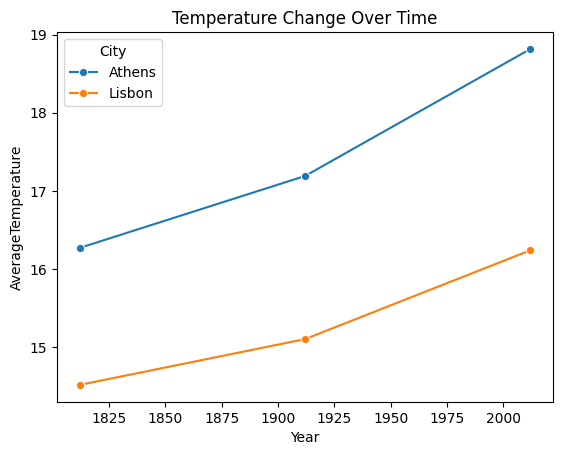

In [10]:
mean_temp = df_years.groupby(["Year", "City"])["AverageTemperature"].mean().reset_index()

sns.lineplot(data=mean_temp, x="Year", y="AverageTemperature", hue="City", marker="o")
plt.title("Temperature Change Over Time")
plt.show()

## Q7 - Direction of Change

A line plot was used to visualize the mean temperature for Lisbon and Athens across the years 1812, 1912, and 2012.

### Interpretation:
- Both cities show a consistent increase in mean temperature over time.
- The direction of change is positive from 1812 to 1912 and from 1912 to 2012 for both Lisbon and Athens.
- This indicates that temperature changes are consistent across periods in both cities.

### Conclusion:
- The sign of change is the same across both time intervals and both cities, suggesting a consistent warming trend.

## Q8 - Critical Discussion

The visualizations used (boxplot and line plot) are effective for providing an initial comparison of temperature patterns between Lisbon and Athens. They are simple, clear, and allow quick identification of differences in central tendency and general trends over time.

However, several limitations should be considered given the nature of the data:

- The boxplot aggregates observations over a very long time period, masking temporal dynamics and potential trends.
- The line plot uses only three discrete time points, which is insufficient to capture continuous climate variability or long-term patterns.
- Both visualizations assume independence of observations, which is not appropriate for time-series data where temporal autocorrelation is expected.
- Variability and uncertainty are not explicitly represented (e.g., no confidence intervals or error bars).
- The large sample size may exaggerate apparent differences, while the visualizations do not reflect sample size or data density.

According to best practices in data visualization (e.g., graphical integrity and clarity), the representations are simple and readable but may oversimplify complex patterns.

### Possible Improvements:
- Use full time-series visualizations to represent temperature evolution over time.
- Include measures of variability (e.g., confidence intervals or standard deviation bands).
- Apply smoothing techniques (e.g., rolling averages) to highlight long-term trends.
- Use faceted plots or separate panels to reduce overplotting and improve clarity.
- Consider interactive dashboards to explore patterns at multiple temporal scales.

### Conclusion:
While the current visualizations are adequate for exploratory analysis, they are limited in capturing the full complexity of the data. More advanced and temporally explicit visualizations would provide a more accurate and informative representation of long-term temperature changes.

## AI Prompts Used

- "How to explore dataset structure using pandas"
- "Compute summary statistics grouped by month and city"
- "Plot comparison between two groups using seaborn"
- "Run t-test in python and interpret results"
- "Non-parametric test for comparing distributions"
- "How to compute effect size in python"
- "How to visualize time series trends in python"
- "How to interpret statistical test results in data analysis"